<a href="https://colab.research.google.com/github/Vinodini1234/Student-Excel-Data-analytics/blob/main/Weather_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statistics
data=pd.read_csv("/content/seattle-weather.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


In [2]:
data.describe()

,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


In [3]:
#average temperature
data["avg_temp"]=(data["temp_max"]+data["temp_min"])
overall_avg_temp=data["avg_temp"].mean()
print("average temperature:",overall_avg_temp)

average temperature: 24.67385352498289


In [4]:
#total temperature
total_temp=data["avg_temp"].sum()
print("total temperature:",total_temp)

total temperature: 36048.5


In [5]:
#total temperature increased
total_inc=(data["avg_temp"][2]-data["avg_temp"][1])
print("total temperature increased:",total_inc)

total temperature increased: 5.5


In [7]:
#prediction
if total_inc<data['avg_temp'].mean():
  print("raining")
else:
  print("no rain")

raining


In [8]:
data["Rain?"] = data["avg_temp"].apply(lambda x: "raining" if total_inc < x else "no rain")
print(data[["date", "avg_temp", "Rain?"]].head())


         date  avg_temp    Rain?
0  2012-01-01      17.8  raining
1  2012-01-02      13.4  raining
2  2012-01-03      18.9  raining
3  2012-01-04      17.8  raining
4  2012-01-05      11.7  raining


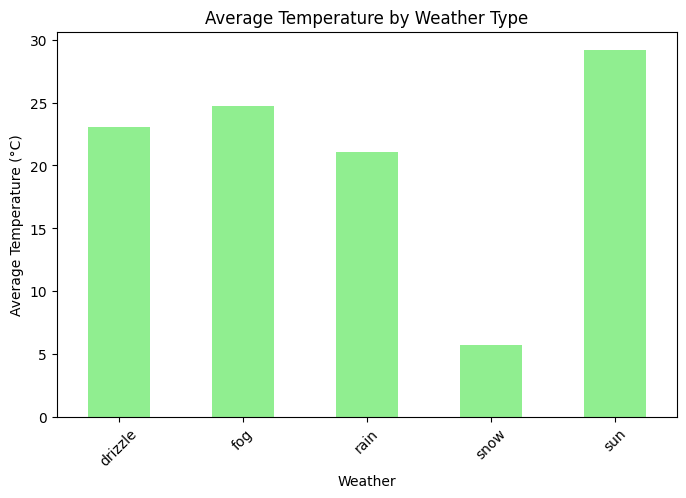

In [20]:
#bar chart for average temperature by wether tpe
avg_temp_by_weather=data.groupby("weather")["avg_temp"].mean()
plt.figure(figsize=(8,5))
avg_temp_by_weather.plot(kind="bar", color="lightgreen")
plt.title("Average Temperature by Weather Type")
plt.xlabel("Weather")
plt.ylabel("Average Temperature (°C)")
plt.xticks(rotation=45)
plt.show()

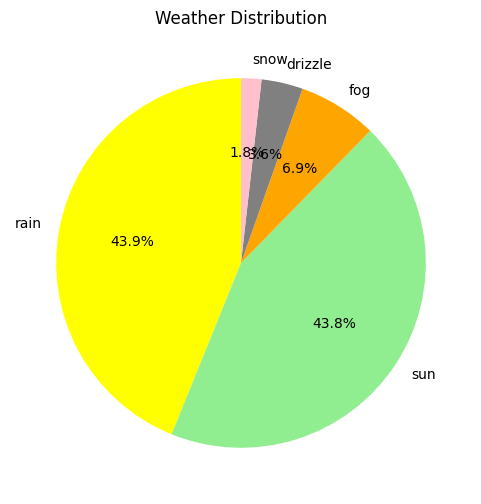

In [15]:
#pie chart for weather distribution
weather_counts = data["weather"].value_counts()
plt.figure(figsize=(6,6))
weather_counts.plot(kind="pie", autopct="%1.1f%%", startangle=90, colors=["yellow","lightgreen","orange","gray","pink"])
plt.title("Weather Distribution")
plt.ylabel("")
plt.show()